In [74]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error, make_scorer
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as plt
import os
import json
from sklearn.model_selection import train_test_split, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from datetime import datetime
from sklearn.linear_model import LinearRegression
from sklearn import linear_model
import xgboost as xgb # xgb.__version__ '2.1.3'
from catboost import CatBoostRegressor
import optuna
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

In [75]:
data=pd.read_excel("../Data/BUS/Bus_FE_Processed.xlsx",engine="openpyxl")
data=data.drop(columns=['COST_INDEX','Unnamed: 0','區議會分區（中文名稱)','Unnamed: 0.1'])

In [76]:
data.rename(columns={
    '按性別劃分的每月主要職業收入（港元）中位數（不包括無酬家庭從業員）.2': 'median_monthly_income_by_gender_excluding_unpaid_family_workers',
    '按房屋類型劃分的有人居住的屋宇單位數目.3': 'occupied_housing_units_by_type',
    '按房屋類型劃分的家庭住戶數目.3': 'households_by_housing_type',
    '家庭住戶每月按揭供款及借貸還款與收入比率中位數': 'median_mortgage_repayment_to_income_ratio',
    '按上課地點劃分的於香港院校就讀全日制課程的人口.2': 'full_time_students_by_institution_location',
    '按廳房數目﹝不包括廚房及廁所﹞劃分的家庭住戶數目.2': 'households_by_number_of_rooms',
    '家庭住戶平均人數': 'average_household_size',
    '按家庭住戶每月按揭供款及借貸還款（港元）劃分的有按揭供款或借貸還款的家庭住戶數目.2': 'households_with_mortgage_by_repayment_amount',
    '按房屋類型劃分的人口.3': 'population_by_housing_type',
    '按行業(9)劃分的工作人口.3': 'working_population_by_industry_9_categories',
    '按家庭住戶每月租金（港元）劃分的居於租住居所的家庭住戶數目': 'households_by_monthly_rent',
    '按行業(9)劃分的工作人口.5': 'working_population_by_industry_5_categories',
    '按工作地點劃分的工作人口.2': 'working_population_by_work_location',
    '按每月主要職業收入（港元）劃分的工作人口（不包括無酬家庭從業員）.4': 'working_population_by_monthly_income_excluding_unpaid_family_workers',
    '按每月主要職業收入（港元）劃分的工作人口（不包括外籍家庭傭工及無酬家庭從業員）.4': 'working_population_by_monthly_income_excluding_foreign_domestic_workers',
    '按住戶人數劃分的家庭住戶數目': 'households_by_size',
    '按住戶結構劃分的家庭住戶數目.6': 'households_by_structure'
}, inplace=True)

In [77]:
data.shape

(4513, 47)

In [78]:
def clean_non_ascii(text):
    if isinstance(text, str):
        return ''.join([char if ord(char) < 128 else '' for char in text])
    return text

data = data.map(clean_non_ascii)

In [79]:
train, test = train_test_split(data, test_size=0.3, random_state=42)

In [80]:
X = train.drop(['PRICE'], axis=1)
y = train['PRICE']
X_test = test.drop(['PRICE'], axis=1)

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2)

In [81]:
import lightgbm as lgb
import time
n_fold = 10

import matplotlib.pyplot as plt
folds = KFold(n_splits=n_fold, shuffle=True, random_state=42)
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

def train_model(X, X_test, y, params=None, folds=folds, model_type='lgb', plot_feature_importance=False, model=None, importance_threshold=0):

    oof = np.zeros(X.shape[0])
    prediction = np.zeros(X_test.shape[0])
    scores = []
    feature_importance = pd.DataFrame()

    # Step 1: Train and record feature importances
    for fold_n, (train_index, valid_index) in enumerate(folds.split(X)):
        print('Fold', fold_n, 'started at', time.ctime())
        if model_type == 'sklearn':
            X_train, X_valid = X[train_index], X[valid_index]
        else:
            X_train, X_valid = X.values[train_index], X.values[valid_index]
        # y_train, y_valid = y[train_index], y[valid_index]
        y_train, y_valid = y.iloc[train_index], y.iloc[valid_index] 

        if model_type == 'lgb':
            model = lgb.LGBMRegressor(**params, n_estimators=20000, nthread=4, n_jobs=-1)
            model.fit(X_train, y_train, 
                      eval_set=[(X_train, y_train), (X_valid, y_valid)], eval_metric='rmse')
            
            y_pred_valid = model.predict(X_valid)
            y_pred = model.predict(X_test, num_iteration=model.best_iteration_)
        
        elif model_type == 'xgb':
            train_data = xgb.DMatrix(data=X_train, label=y_train)
            valid_data = xgb.DMatrix(data=X_valid, label=y_valid)

            watchlist = [(train_data, 'train'), (valid_data, 'valid_data')]
            model = xgb.train(dtrain=train_data, num_boost_round=20000, evals=watchlist, early_stopping_rounds=200, verbose_eval=500, params=params)
            y_pred_valid = model.predict(xgb.DMatrix(X_valid), iteration_range=(0, model.best_iteration + 1))
            y_pred = model.predict(xgb.DMatrix(X_test.values),  iteration_range=(0, model.best_iteration + 1))
        
        elif model_type == 'sklearn':
            model = model
            model.fit(X_train, y_train)
            y_pred_valid = model.predict(X_valid).reshape(-1,)
            score = mean_squared_error(y_valid, y_pred_valid)
            
            y_pred = model.predict(X_test)
        
        elif model_type == 'cat':
            model = CatBoostRegressor(iterations=20000,  eval_metric='RMSE', **params)
            model.fit(X_train, y_train, eval_set=(X_valid, y_valid), cat_features=[], use_best_model=True, verbose=False)

            y_pred_valid = model.predict(X_valid)
            y_pred = model.predict(X_test)

        elif model_type == 'randomforest':
            model = RandomForestRegressor(**params, n_jobs=-1, random_state=42)
            model.fit(X_train, y_train)
            y_pred_valid = model.predict(X_valid)
            y_pred = model.predict(X_test)

        oof[valid_index] = y_pred_valid.reshape(-1,)
        mse = mean_squared_error(y_valid, y_pred_valid) ** 0.5
        print("mse----------->", mse)
        scores.append(mse)
        
        prediction += y_pred    

        if model_type == 'lgb':
            # Calculate feature importance for each fold
            fold_importance = pd.DataFrame()
            fold_importance["feature"] = X.columns
            fold_importance["importance"] = model.feature_importances_
            fold_importance["fold"] = fold_n + 1
            feature_importance = pd.concat([feature_importance, fold_importance], axis=0)
        elif model_type =='randomforest':
            # Calculate feature importance for each fold
            fold_importance = pd.DataFrame()
            fold_importance["feature"] = X.columns
            fold_importance["importance"] = model.feature_importances_
            fold_importance["fold"] = fold_n + 1
            feature_importance = pd.concat([feature_importance, fold_importance], axis=0)

    prediction /= folds.n_splits
    
    print('CV mean score: {0:.4f}, std: {1:.4f}.'.format(np.mean(scores), np.std(scores)))

    if model_type == 'lgb':
        feature_importance["importance"] /= folds.n_splits

        # Optional: Plot feature importance if specified
        if plot_feature_importance:
            cols = feature_importance[["feature", "importance"]].groupby("feature").mean().sort_values(
                by="importance", ascending=False)[:50].index
            best_features = feature_importance.loc[feature_importance.feature.isin(cols)]

            plt.figure(figsize=(16, 12))
            sns.barplot(x="importance", y="feature", data=best_features.sort_values(by="importance", ascending=False))
            plt.title('LGB Features (avg over folds)')
            return oof, prediction, feature_importance
        return oof, prediction, feature_importance            
    elif model_type =='randomforest':
        feature_importance["importance"] /= folds.n_splits
        if plot_feature_importance:
            #plot the frature importance 
            cols = feature_importance.groupby("feature")["importance"].mean().sort_values(ascending=False)[:50].index
            best_features = feature_importance[feature_importance["feature"].isin(cols)]

            # 绘制条形图
            plt.figure(figsize=(16, 12))
            sns.barplot(x="importance", y="feature", data=best_features.sort_values(by="importance", ascending=False))
            plt.title('Random Forest Feature Importance (Avg over Folds)')
            plt.tight_layout()
            return oof, prediction, feature_importance
        return oof, prediction, feature_importance

    else:
        return oof, prediction


In [82]:
X_train_np = X_train.values
y_train_np = y_train.values
X_valid_np = X_valid.values
y_valid_np = y_valid.values
X_train_np = np.nan_to_num(X_train_np, nan=0)
X_valid_np = np.nan_to_num(X_valid_np, nan=0)

from xgboost.callback import EarlyStopping
from lightgbm import early_stopping, log_evaluation

def objective(trial, model_type):
    if model_type == 'xgboost':
        param = {
            'objective': 'reg:squarederror',
            'eta': trial.suggest_float('eta', 0.01, 0.3, log=True),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'lambda': trial.suggest_float('lambda', 1e-8, 10.0, log=True),
            'alpha': trial.suggest_float('alpha', 1e-8, 10.0, log=True),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
            'eval_metric':'rmse',
            'early_stopping_rounds':50,
            'n_estimators': 1000
        }
        model = xgb.XGBRegressor(**param, n_jobs=-1, random_state=42)

    elif model_type == 'lightgbm':
        param = {
            'objective': 'regression',
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'max_depth': trial.suggest_int('max_depth', -1, 10),
            'num_leaves': trial.suggest_int('num_leaves', 2, 256),
            'feature_fraction': trial.suggest_float('feature_fraction', 0.6, 1.0),
            'bagging_fraction': trial.suggest_float('bagging_fraction', 0.6, 1.0),
            'lambda_l1': trial.suggest_float('lambda_l1', 1e-8, 10.0, log=True),
            'lambda_l2': trial.suggest_float('lambda_l2', 1e-8, 10.0, log=True),
            'min_child_samples': trial.suggest_int('min_child_samples', 1, 20),
            'n_estimators': 1000,
            'verbosity': -1  # Suppress warnings
        }
        model = lgb.LGBMRegressor(**param, n_jobs=-1, random_state=42)

        callbacks = [early_stopping(stopping_rounds=50, verbose=False)]

    elif model_type == 'catboost':
        param = {
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'depth': trial.suggest_int('depth', 3, 10),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-8, 10.0, log=True),
            'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 10.0),
            'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.6, 1.0),
            'od_wait': trial.suggest_int('od_wait', 10, 200),
            'iterations': 1000,
            'eval_metric': 'RMSE',  # Specify evaluation metric here
            'random_state': 42,
            'silent': True  # Suppress output
        }
        model = CatBoostRegressor(**param)
    elif model_type == 'randomforest':
        param = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
            'max_depth': trial.suggest_int('max_depth', 3, 30),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
            'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
            'random_state': 42,
            'n_jobs': -1
        }
        model = RandomForestRegressor(**param)


    else:
        raise ValueError(f"Unknown model type: {model_type}")

    # Train the model
    if model_type == 'lightgbm':
        model.fit(
            X_train_np, y_train_np,
            eval_set=[(X_valid_np, y_valid_np)],
            eval_metric='rmse',
            callbacks=callbacks
        )
    elif model_type == 'catboost':
        model.fit(
            X_train_np, y_train_np,
            eval_set=[(X_valid_np, y_valid_np)]
        )
    elif model_type=='randomforest':
        model.fit(
            X_train_np, y_train_np
        )
    else:
        model.fit(
            X_train_np, y_train_np,
            eval_set=[(X_valid_np, y_valid_np)],
            #early_stopping_rounds=50,  
            verbose=False
        )

    # Predict and calculate RMSE
    y_pred = model.predict(X_valid_np)
    rmse = np.sqrt(mean_squared_error(y_valid_np, y_pred))
    return rmse

def optimize_model(model_type, n_trials=50):
    def wrapped_objective(trial):
        return objective(trial, model_type)

    study = optuna.create_study(direction='minimize')
    study.optimize(wrapped_objective, n_trials=n_trials)
    print(f"Best parameters for {model_type}:")
    print(study.best_trial.params)
    print(f"Best RMSE for {model_type}: {study.best_trial.value}")
    return study




In [68]:
lgb_study = optimize_model('lightgbm')

[I 2025-03-15 15:27:38,224] A new study created in memory with name: no-name-7f5b41a4-9089-4ad4-93b7-4c02255bddce
[I 2025-03-15 15:27:38,494] Trial 0 finished with value: 1.265218225135946 and parameters: {'learning_rate': 0.01157077842317934, 'max_depth': 2, 'num_leaves': 168, 'feature_fraction': 0.618192819268808, 'bagging_fraction': 0.9875229934015196, 'lambda_l1': 2.0220494617552442e-08, 'lambda_l2': 6.645837491367319e-06, 'min_child_samples': 7}. Best is trial 0 with value: 1.265218225135946.
[I 2025-03-15 15:27:39,489] Trial 1 finished with value: 0.9516477732530311 and parameters: {'learning_rate': 0.03866649533681255, 'max_depth': 0, 'num_leaves': 122, 'feature_fraction': 0.7262119670198226, 'bagging_fraction': 0.9092173471376414, 'lambda_l1': 0.0017218477129515694, 'lambda_l2': 7.204436356428827e-07, 'min_child_samples': 12}. Best is trial 1 with value: 0.9516477732530311.
[I 2025-03-15 15:27:39,843] Trial 2 finished with value: 1.2268769448119794 and parameters: {'learning_ra

KeyboardInterrupt: 

Fold 0 started at Sat Mar 15 12:38:05 2025


mse-----------> 1.1261242923981543
Fold 1 started at Sat Mar 15 12:39:22 2025
mse-----------> 0.979704815776785
Fold 2 started at Sat Mar 15 12:40:29 2025
mse-----------> 0.9714188362860335
Fold 3 started at Sat Mar 15 12:41:30 2025
mse-----------> 1.0313661957589084
Fold 4 started at Sat Mar 15 12:42:23 2025
mse-----------> 1.0139269891008342
Fold 5 started at Sat Mar 15 12:43:16 2025
mse-----------> 1.114341646926683
Fold 6 started at Sat Mar 15 12:44:12 2025
mse-----------> 1.0741022073739286
Fold 7 started at Sat Mar 15 12:45:06 2025
mse-----------> 1.035386411460807
Fold 8 started at Sat Mar 15 12:46:11 2025
mse-----------> 0.8928904882831233
Fold 9 started at Sat Mar 15 12:47:15 2025
mse-----------> 1.2147624669029495
CV mean score: 1.0454, std: 0.0867.


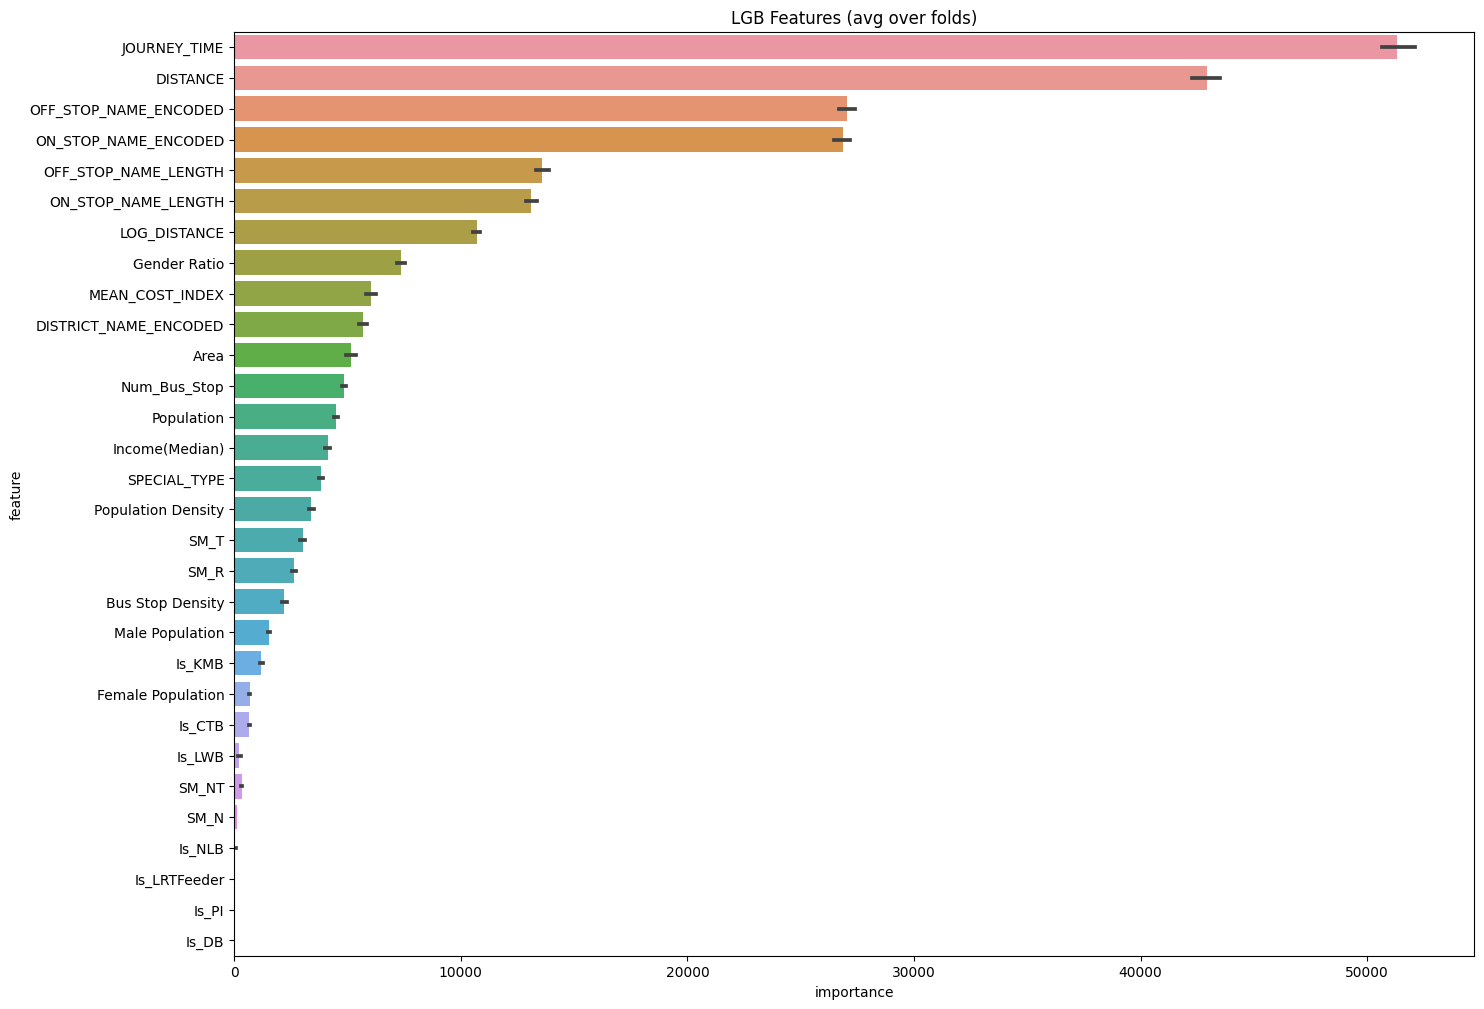

In [21]:
oof_lgb, prediction_lgb, _ = train_model(X, X_test, y, params=lgb_study.best_params, model_type='lgb', plot_feature_importance=True)


In [84]:
rf_study = optimize_model('randomforest', n_trials=50)

[I 2025-03-15 15:32:40,747] A new study created in memory with name: no-name-691e3517-89f0-4702-ae91-b096c409407e
[I 2025-03-15 15:32:41,316] Trial 0 finished with value: 1.2923459296131479 and parameters: {'n_estimators': 355, 'max_depth': 17, 'min_samples_split': 15, 'min_samples_leaf': 2, 'max_features': 'log2'}. Best is trial 0 with value: 1.2923459296131479.
[I 2025-03-15 15:32:41,674] Trial 1 finished with value: 1.365062801322124 and parameters: {'n_estimators': 181, 'max_depth': 27, 'min_samples_split': 3, 'min_samples_leaf': 8, 'max_features': 'sqrt'}. Best is trial 0 with value: 1.2923459296131479.
[I 2025-03-15 15:32:42,930] Trial 2 finished with value: 1.478524479437352 and parameters: {'n_estimators': 960, 'max_depth': 6, 'min_samples_split': 13, 'min_samples_leaf': 6, 'max_features': 'log2'}. Best is trial 0 with value: 1.2923459296131479.
[I 2025-03-15 15:32:43,258] Trial 3 finished with value: 1.5392599826831572 and parameters: {'n_estimators': 267, 'max_depth': 4, 'min

Best parameters for randomforest:
{'n_estimators': 608, 'max_depth': 22, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt'}
Best RMSE for randomforest: 1.1631665464789067


Fold 0 started at Sat Mar 15 15:33:37 2025


e:\Users\非衣\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


mse-----------> 1.1259868530274135
Fold 1 started at Sat Mar 15 15:33:38 2025


e:\Users\非衣\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


mse-----------> 1.0695162453255667
Fold 2 started at Sat Mar 15 15:33:39 2025


...

mse-----------> 1.0784526340656575
Fold 8 started at Sat Mar 15 15:33:47 2025


e:\Users\非衣\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


mse-----------> 0.8788121423531149
Fold 9 started at Sat Mar 15 15:33:48 2025


e:\Users\非衣\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


mse-----------> 1.094761093841701
CV mean score: 1.0616, std: 0.0721.


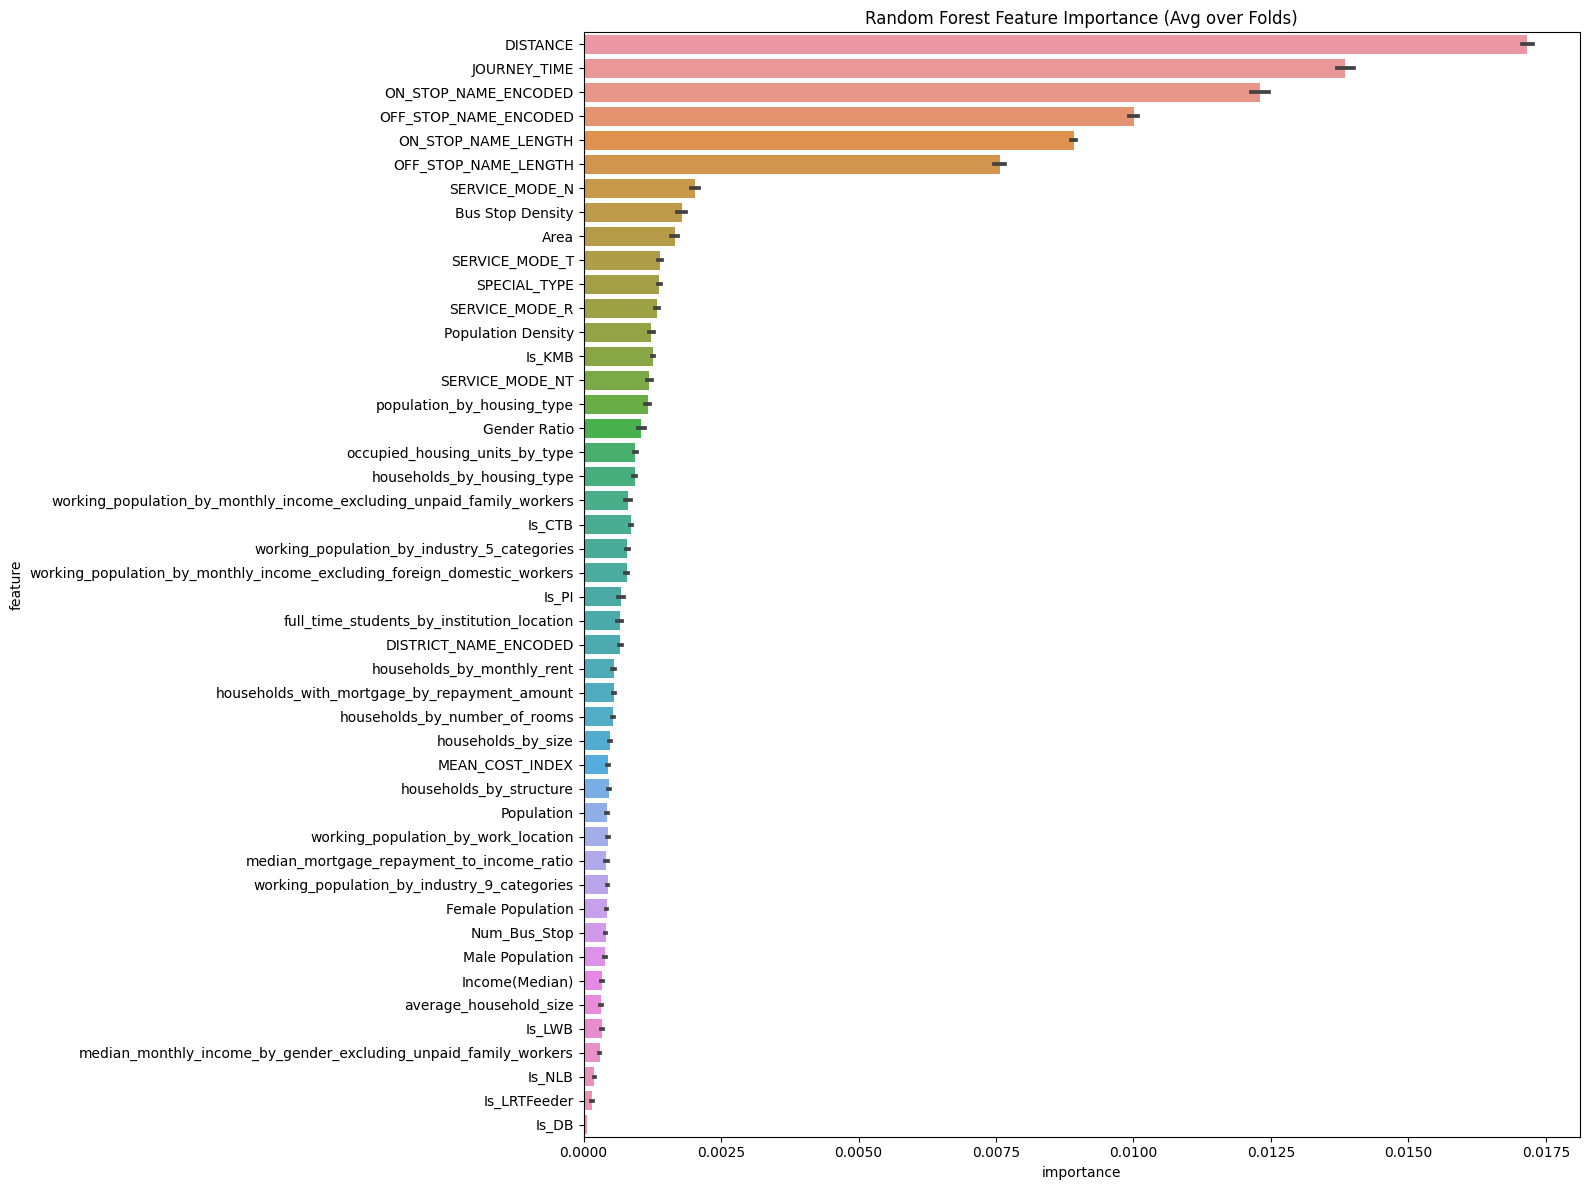

In [85]:
oof_rf, prediction_rf,feature_importance= train_model(X, X_test, y, params=rf_study.best_params, model_type='randomforest', plot_feature_importance=True)


In [24]:
catboost_study = optimize_model('catboost')

[I 2025-03-15 12:49:15,474] A new study created in memory with name: no-name-52ef56ab-e28a-4788-8a59-41eb3fa70ef1


[I 2025-03-15 12:49:18,705] Trial 0 finished with value: 1.0906075269521143 and parameters: {'learning_rate': 0.01515825990880944, 'depth': 7, 'l2_leaf_reg': 0.37320435253799256, 'bagging_temperature': 5.094032931550466, 'colsample_bylevel': 0.8113205750260366, 'od_wait': 185}. Best is trial 0 with value: 1.0906075269521143.
[I 2025-03-15 12:49:23,858] Trial 1 finished with value: 1.0380763365004422 and parameters: {'learning_rate': 0.07428480112609252, 'depth': 10, 'l2_leaf_reg': 0.008269676719382946, 'bagging_temperature': 9.158834415648007, 'colsample_bylevel': 0.640807879979266, 'od_wait': 84}. Best is trial 1 with value: 1.0380763365004422.
[I 2025-03-15 12:49:24,934] Trial 2 finished with value: 1.035232407961895 and parameters: {'learning_rate': 0.16864717637963791, 'depth': 7, 'l2_leaf_reg': 0.00012610036043121675, 'bagging_temperature': 0.20972572074511087, 'colsample_bylevel': 0.7113166696478095, 'od_wait': 95}. Best is trial 2 with value: 1.035232407961895.
[I 2025-03-15 12:

Best parameters for catboost:
{'learning_rate': 0.10022466055717864, 'depth': 8, 'l2_leaf_reg': 1.0844775943502943e-06, 'bagging_temperature': 1.8058394183527948, 'colsample_bylevel': 0.8813137431537428, 'od_wait': 161}
Best RMSE for catboost: 0.9903157668003731


In [25]:

oof_cat, prediction_cat = train_model(X, X_test, y, params=catboost_study.best_params, model_type='cat')


Fold 0 started at Sat Mar 15 12:51:45 2025
mse-----------> 1.1304574515496901
Fold 1 started at Sat Mar 15 12:51:47 2025
mse-----------> 1.0124328988391422
Fold 2 started at Sat Mar 15 12:51:53 2025
mse-----------> 0.9401744686985376
Fold 3 started at Sat Mar 15 12:51:58 2025
mse-----------> 1.0020677053896045
Fold 4 started at Sat Mar 15 12:52:05 2025
mse-----------> 0.9965234866887955
Fold 5 started at Sat Mar 15 12:52:07 2025
mse-----------> 1.1118683359799075
Fold 6 started at Sat Mar 15 12:52:11 2025
mse-----------> 1.076633891258788
Fold 7 started at Sat Mar 15 12:52:16 2025
mse-----------> 0.9851943944521584
Fold 8 started at Sat Mar 15 12:52:21 2025
mse-----------> 0.8001853443505426
Fold 9 started at Sat Mar 15 12:52:26 2025
mse-----------> 1.131130085332702
CV mean score: 1.0187, std: 0.0964.


In [87]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
lgb_rmse = np.sqrt(mean_squared_error(test['PRICE'], prediction_lgb))
rf_rmse=np.sqrt(mean_squared_error(test['PRICE'], prediction_rf))
cat_rmse=np.sqrt(mean_squared_error(test['PRICE'], prediction_cat))
lgb_r2=r2_score(test['PRICE'], prediction_lgb)
rf_r2=r2_score(test['PRICE'], prediction_rf)
cat_r2=r2_score(test['PRICE'], prediction_cat)
print(prediction_lgb)


print("LGB_RMSE:", lgb_rmse)
print("RF_RMSE:", rf_rmse)
print("CAT_RMSE:", cat_rmse)
print('LGB_R2: ', lgb_r2)
print('LGB_R2: ', rf_r2)
print('LGB_R2: ', cat_r2)


LGB_RMSE: 0.9695184713777311
RF_RMSE: 1.0413756946298227
CAT_RMSE: 0.9607748284732851
LGB_R2:  0.6602508533711711
LGB_R2:  0.6080225588846229
LGB_R2:  0.6663513039730437
